<a href="https://colab.research.google.com/github/e23191-eng/Statistical-Learning-e23191-/blob/main/Assignment_07_c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 7c: Item Response Prediction and Click Through Rate Prediction**

# Part 1: Bayesian Estimation of a User Ability Parameter from Item Responses

**1. Visualizing the Mechanics & Interpretations**

The Two-Parameter Logistic (2PL) Item Response Theory (IRT) model defines the probability of a user with latent ability $\theta$ answering item $i$ correctly as:$$P(Y_i=1 \mid \Theta=\theta) = p_i(\theta) = \frac{1}{1+e^{-a_i(\theta-b_i)}}$$Discrimination ($a_i > 0$): Controls the steepness (slope) of the curve at $\theta = b_i$. A high $a_i$ creates a sharp threshold that clearly distinguishes abilities above versus below $b_i$.Difficulty ($b_i$): Represents the location parameter along the horizontal axis where $p_i(b_i) = 0.5$. Increasing $b_i$ shifts the entire response curve horizontally to the right, meaning a higher latent ability $\theta$ is required to achieve a $50\%$ probability of answering correctly.

<>:35: SyntaxWarning: invalid escape sequence '\T'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\T'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\T'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\T'
<>:55: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_610/1395769843.py:35: SyntaxWarning: invalid escape sequence '\T'
  ax1.set_xlabel("User Ability ($\Theta$)", fontsize=10)
/tmp/ipykernel_610/1395769843.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("Probability of Correct Answer $P(Y_i=1 \mid \Theta)$", fontsize=10)
/tmp/ipykernel_610/1395769843.py:54: SyntaxWarning: invalid escape sequence '\T'
  ax2.set_xlabel("User Ability ($\Theta$)", fontsize=10)
/tmp/ipykernel_610/1395769843.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Probability of Correct Answer $P(Y_i=1 \mid \Theta

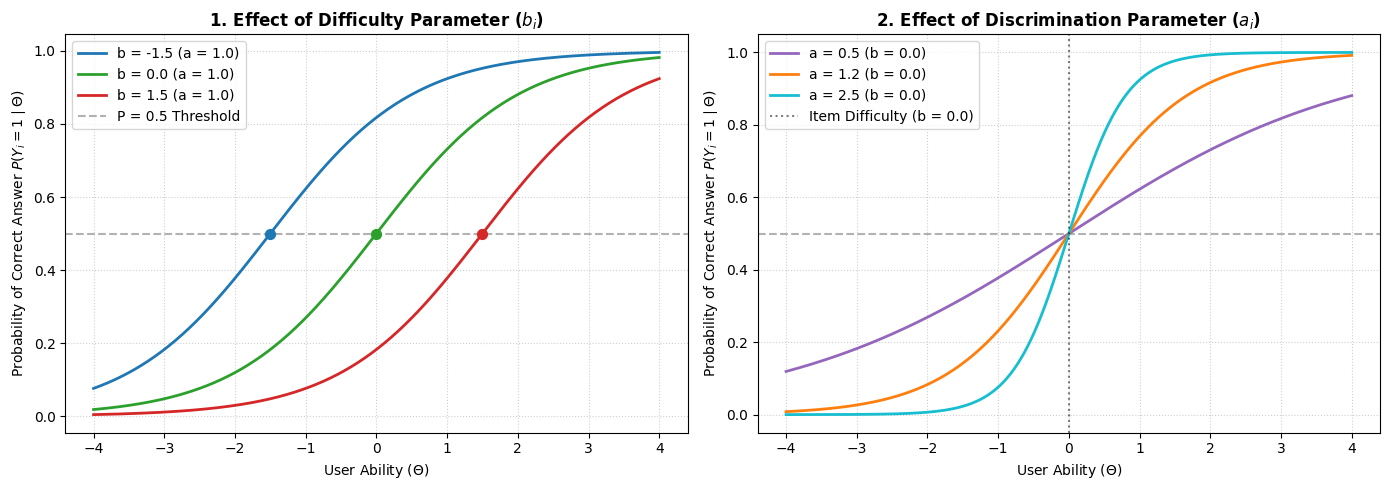

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the 2PL IRT Probability Function
def p_i(theta, a, b):
    """
    Computes probability of a correct response under 2PL IRT.
    theta: Latent ability
    a: Discrimination parameter (slope)
    b: Difficulty parameter (location shift)
    """
    return 1.0 / (1.0 + np.exp(-a * (theta - b)))

# Ability grid for plotting
theta_vals = np.linspace(-4, 4, 500)

# Create figure with two subplots to isolate 'b' and 'a'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------
# Subplot 1: Effect of Difficulty (b) with Constant Discrimination (a = 1.0)
# -------------------------------------------------------------
a_fixed = 1.0
b_values = [-1.5, 0.0, 1.5]
colors_b = ['#1f77b4', '#2ca02c', '#d62728']

for b_val, color in zip(b_values, colors_b):
    prob = p_i(theta_vals, a_fixed, b_val)
    ax1.plot(theta_vals, prob, label=f'b = {b_val} (a = {a_fixed})', color=color, linewidth=2)
    # Highlight the 50% probability point at theta = b
    ax1.scatter([b_val], [0.5], color=color, s=50, zorder=5)

ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='P = 0.5 Threshold')
ax1.set_title("1. Effect of Difficulty Parameter ($b_i$)", fontsize=12, fontweight='bold')
ax1.set_xlabel("User Ability ($\Theta$)", fontsize=10)
ax1.set_ylabel("Probability of Correct Answer $P(Y_i=1 \mid \Theta)$", fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

# -------------------------------------------------------------
# Subplot 2: Effect of Discrimination (a) with Constant Difficulty (b = 0.0)
# -------------------------------------------------------------
b_fixed = 0.0
a_values = [0.5, 1.2, 2.5]
colors_a = ['#9467bd', '#ff7f0e', '#17becf']

for a_val, color in zip(a_values, colors_a):
    prob = p_i(theta_vals, a_val, b_fixed)
    ax2.plot(theta_vals, prob, label=f'a = {a_val} (b = {b_fixed})', color=color, linewidth=2)

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax2.axvline(b_fixed, color='black', linestyle=':', alpha=0.5, label='Item Difficulty (b = 0.0)')
ax2.set_title("2. Effect of Discrimination Parameter ($a_i$)", fontsize=12, fontweight='bold')
ax2.set_xlabel("User Ability ($\Theta$)", fontsize=10)
ax2.set_ylabel("Probability of Correct Answer $P(Y_i=1 \mid \Theta)$", fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**2. Sequential Likelihood Contribution**

For a single item response $y_k \in \{0, 1\}$ at step $k$:$$L(y_k \mid \theta) = p_k(\theta)^{y_k} \left[1 - p_k(\theta)\right]^{1 - y_k}$$Assuming conditional independence given $\Theta = \theta$, the joint likelihood function for the running history vector $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ is:$$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^k L(y_i \mid \theta) = \prod_{i=1}^k \left[p_i(\theta)\right]^{y_i} \left[1 - p_i(\theta)\right]^{1 - y_i}$$

**3. Mathematical Formulation of the Running Update**

Using the posterior distribution from step $k-1$ as the prior distribution for step $k$, the recursive update relationship (up to a proportionality constant) is:$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$Including the normalization denominator:$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) = \frac{p_k(\theta)^{y_k} (1 - p_k(\theta))^{1 - y_k} \, f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})}{\int_{-\infty}^{\infty} p_k(s)^{y_k} (1 - p_k(s))^{1 - y_k} \, f_{\Theta \mid \mathbf{Y}^{(k-1)}}(s \mid \mathbf{y}^{(k-1)}) \, ds}$$where $f_{\Theta \mid \mathbf{Y}^{(0)}}(\theta \mid \mathbf{y}^{(0)}) = f_\Theta^{(0)}(\theta) = \frac{1}{\sqrt{2\pi}}\exp\left(-\frac{\theta^2}{2}\right)$

**4. Dynamic Shifting Mechanics**

When a user answers a highly difficult item ($b_k \gg 0$) correctly ($y_k = 1$), the likelihood function $L(y_k=1 \mid \theta) = p_k(\theta)$ assigns very low weight to lower $\theta$ values and approaches $1.0$ for high $\theta$ values.Multiplying the prior density by this monotonically increasing likelihood multiplies down the left side of the distribution, significantly pushing and shifting the mode (peak) of the posterior density curve to the right. This represents a strong Bayesian belief update that the user possesses high ability

**5. Tracking Certainty and Sharpness**

The discrimination parameter $a_k$ dictates the information content of the update:

Large $a_k$ (High Discrimination): The likelihood $p_k(\theta)$ changes very rapidly near $\theta = b_k$, acting almost like a step function. Multiplying by this sharp curve significantly reduces posterior variance (sharpening the distribution peak) and yields high certainty about whether $\theta > b_k$ or $\theta < b_k$.

Very Small $a_k$ (Low Discrimination): The likelihood function is nearly flat across a wide domain. Multiplying by a flat function leaves the posterior density virtually unchanged, injecting very little information and maintaining the existing level of uncertainty.

**6. Numerical Implementation via Fixed Grid**

Because the 2PL IRT model lacks an analytical conjugate prior, updates are tracked on a discrete grid of ability values $\{\theta_m\}_{m=1}^M \in [\theta_{\min}, \theta_{\max}]$:

Grid Evaluation: Evaluate the likelihood array across the grid: $\mathbf{L}_k = L(y_k \mid \boldsymbol{\theta})$.

Unnormalized Update: Compute point-wise product: $\tilde{\mathbf{P}}_k = \mathbf{L}_k \odot \mathbf{P}_{k-1}$.

Sequential Normalization: Approximate the integral constant $Z_k$ using the composite trapezoidal rule:$$Z_k = \text{trapezoid}(\tilde{\mathbf{P}}_k, \boldsymbol{\theta})$$

Normalized State: Update the grid state: $\mathbf{P}_k = \frac{\tilde{\mathbf{P}}_k}{Z_k}$.

**7. Python Implementation & Convergence Simulation (20-Item Adaptive Tracking)**

In [2]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go

# Set seed for reproducible stochastic response generation
np.random.seed(42)

# 1. Problem Setup
theta_true = 0.75
n_items = 20
theta_grid = np.linspace(-5, 5, 1000)  # Fine computational grid

# 2. 2PL Model Probability Function
def p_i(theta, a, b):
    return 1 / (1 + np.exp(-a * (theta - b)))

# 3. Generate Random Item Properties
a_params = np.random.uniform(0.5, 2.0, size=n_items)
b_params = np.random.normal(0, 1, size=n_items)

# 4. Initialize Prior State: Standard Normal N(0,1)
current_posterior = stats.norm.pdf(theta_grid, 0, 1)
current_posterior /= np.trapezoid(current_posterior, theta_grid)

# Initialize tracking arrays (Step 0)
running_bayes = [np.trapezoid(theta_grid * current_posterior, theta_grid)]
running_map = [theta_grid[np.argmax(current_posterior)]]
steps = list(range(n_items + 1))

# 5. Sequential Bayesian Simulation Loop
for k in range(n_items):
    a_k = a_params[k]
    b_k = b_params[k]

    # Generate user response stochastically based on true ability
    prob_true = p_i(theta_true, a_k, b_k)
    y_k = 1 if np.random.uniform(0, 1) < prob_true else 0

    # Calculate likelihood curve across grid
    prob_grid = p_i(theta_grid, a_k, b_k)
    likelihood = (prob_grid ** y_k) * ((1 - prob_grid) ** (1 - y_k))

    # Sequential Bayesian update and trapezoidal normalization
    current_posterior = current_posterior * likelihood
    integral = np.trapezoid(current_posterior, theta_grid)
    current_posterior /= integral

    # Compute point estimators
    bayes_est = np.trapezoid(theta_grid * current_posterior, theta_grid)
    map_est = theta_grid[np.argmax(current_posterior)]

    running_bayes.append(bayes_est)
    running_map.append(map_est)

# 6. Interactive Visualization using Plotly
fig = go.Figure()

# Add True Ability Reference Line
fig.add_hline(
    y=theta_true, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"True Ability (θ = {theta_true})", annotation_position="bottom right"
)

# Add Posterior Mean Line
fig.add_trace(go.Scatter(
    x=steps, y=running_bayes, mode='lines+markers',
    name='Posterior Mean (θ̂_Bayes)', line=dict(color='blue', width=2.5), marker=dict(size=6)
))

# Add MAP Line
fig.add_trace(go.Scatter(
    x=steps, y=running_map, mode='lines+markers',
    name='MAP Estimate (θ̂_MAP)', line=dict(color='green', width=2, dash='dot'), marker=dict(size=6, symbol='square')
))

fig.update_layout(
    title={'text': "Progression of Ability Estimators (θ) Over 20 Items", 'y': 0.93, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Sequence / Item Position (k)", yaxis_title="Estimated Ability (θ̂)",
    xaxis=dict(tickmode='linear', tick0=0, dtick=2), yaxis=dict(range=[-1.0, 2.0]),
    template="plotly_white", hovermode="x unified",
    legend=dict(yanchor="bottom", y=0.05, xanchor="right", x=0.98)
)

fig.show()

**Analysis of Results**

As $k$ increases, both $\widehat{\theta}_{\text{Bayes}}^{(k)}$ and $\widehat{\theta}_{\text{MAP}}^{(k)}$ converge towards $\theta_{\text{true}} = 0.75$. Early steps display larger oscillations due to individual response noise, but cumulative observations reduce variance, narrowing the posterior density around the true parameter value.

# Question 2: Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates

**1. Structural Probability & Beta Distribution Properties**

The Beta density parameterized by shape parameters $\alpha, \beta > 0$ over $\theta \in [0, 1]$ is:$$f(\theta \mid \alpha, \beta) = \frac{1}{\mathrm{B}(\alpha, \beta)} \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$$

Uninformative $(\alpha=1, \beta=1)$: Yields a uniform flat distribution over $[0, 1]$.

Right-Skewed $(\alpha=2, \beta=8)$: Center of mass shifts left toward 0 (mean $\frac{2}{10} = 0.2$), reflecting a prior belief of low click rates.

Left-Skewed $(\alpha=8, \beta=2)$: Center of mass shifts right toward 1 (mean $\frac{8}{10} = 0.8$), reflecting a prior belief of high click rates.

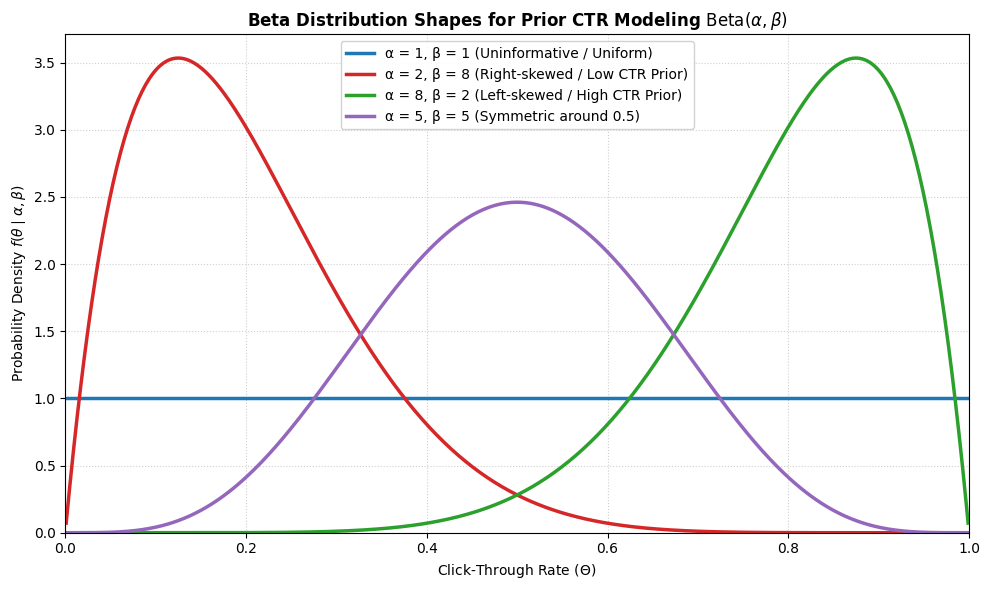

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define grid of CTR (theta) values between 0 and 1
theta_vals = np.linspace(0.001, 0.999, 500)

# Configure Beta distribution cases to demonstrate
beta_cases = [
    {'alpha': 1, 'beta': 1, 'label': 'α = 1, β = 1 (Uninformative / Uniform)', 'color': '#1f77b4'},
    {'alpha': 2, 'beta': 8, 'label': 'α = 2, β = 8 (Right-skewed / Low CTR Prior)', 'color': '#d62728'},
    {'alpha': 8, 'beta': 2, 'label': 'α = 8, β = 2 (Left-skewed / High CTR Prior)', 'color': '#2ca02c'},
    {'alpha': 5, 'beta': 5, 'label': 'α = 5, β = 5 (Symmetric around 0.5)', 'color': '#9467bd'}
]

plt.figure(figsize=(10, 6))

# Plot PDF for each parameter pair
for case in beta_cases:
    a, b = case['alpha'], case['beta']
    pdf_vals = beta.pdf(theta_vals, a, b)
    plt.plot(theta_vals, pdf_vals, label=case['label'], color=case['color'], linewidth=2.5)

# Formatting plot
plt.title("Beta Distribution Shapes for Prior CTR Modeling $\\text{Beta}(\\alpha, \\beta)$", fontsize=12, fontweight='bold')
plt.xlabel("Click-Through Rate $(\\Theta)$", fontsize=10)
plt.ylabel("Probability Density $f(\\theta \\mid \\alpha, \\beta)$", fontsize=10)
plt.xlim(0, 1)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper center', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

**2. Sequential Likelihood and Joint History**

For a single Bernoulli interaction $y_k \in \{0, 1\}$:$$L(y_k \mid \theta) = \theta^{y_k} (1 - \theta)^{1 - y_k}$$For a running history vector $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ with $C_k = \sum_{i=1}^k y_i$ total clicks:$$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^k \theta^{y_i} (1 - \theta)^{1 - y_i} = \theta^{C_k} (1 - \theta)^{k - C_k}$$

**3. Closed-Form Analytical Updates (Beta-Binomial Conjugacy)**

Applying Bayes' Theorem recursively:$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$Substituting the Beta prior from step $k-1$ and the single likelihood:$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto \left[\theta^{y_k} (1 - \theta)^{1 - y_k}\right] \cdot \left[\theta^{\alpha_{k-1} - 1} (1 - \theta)^{\beta_{k-1} - 1}\right] = \theta^{(\alpha_{k-1} + y_k) - 1} (1 - \theta)^{(\beta_{k-1} + 1 - y_k) - 1}$$

Because the functional form matches a Beta distribution, conjugacy is proven with simple arithmetic parameter updates:$$\alpha_k = \alpha_{k-1} + y_k, \qquad \beta_k = \beta_{k-1} + (1 - y_k)$$

**4. Dynamic Shifting Mechanics**

Click ($y_k = 1$): Increments $\alpha_k$ by 1, multiplying the density function by $\theta$. This pulls probability weight toward 1, shifting the distribution peak rightward.

Non-Click ($y_k = 0$): Increments $\beta_k$ by 1, multiplying the density function by $(1 - \theta)$. This pulls probability weight toward 0, shifting the distribution peak leftward.

Conjugate vs. Non-Conjugate (2PL IRT): Beta-Binomial conjugacy allows exact updating by modifying scalar parameters $(\alpha_k, \beta_k)$ in $\mathcal{O}(1)$ computational complexity. Non-conjugate models (like 2PL IRT) require maintaining and integrating numerical arrays across discretization grids.

**5. Running Point Estimators**

Running Posterior Mean ($\widehat{\theta}_{\text{Bayes}}^{(k)}$):$$\widehat{\theta}_{\text{Bayes}}^{(k)} = \mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}] = \frac{\alpha_k}{\alpha_k + \beta_k} = \frac{\alpha_0 + C_k}{\alpha_0 + \beta_0 + k}$$Running Maximum A Posteriori ($\widehat{\theta}_{\text{MAP}}^{(k)}$):$$\widehat{\theta}_{\text{MAP}}^{(k)} = \begin{cases} \frac{\alpha_k - 1}{\alpha_k + \beta_k - 2}, & \text{if } \alpha_k > 1 \text{ and } \beta_k > 1 \\ 0, & \text{if } \alpha_k \le 1, \beta_k > 1 \\ 1, & \text{if } \alpha_k > 1, \beta_k \le 1 \end{cases}$$

**6. Python Simulation & Convergence Analysis (100 Impressions)**

In [3]:
import numpy as np
import plotly.graph_objects as go

# Seed for reproducible response stream
np.random.seed(42)

# 1. Setup Simulation
theta_true = 0.35
n_impressions = 100
steps = list(range(n_impressions + 1))

# Initialize Beta Prior: Beta(1,1) (Uniform state)
alpha_k = 1
beta_k = 1

running_bayes = [alpha_k / (alpha_k + beta_k)]
running_map = [0.0]  # Standard mode default for uniform prior

# 2. Closed-Form Update Loop
for k in range(1, n_impressions + 1):
    # Simulate Bernoulli impression response
    y_k = 1 if np.random.uniform(0, 1) < theta_true else 0

    # Analytical conjugate update
    alpha_k += y_k
    beta_k += (1 - y_k)

    # Calculate closed-form point estimates
    bayes_est = alpha_k / (alpha_k + beta_k)

    if alpha_k > 1 and beta_k > 1:
        map_est = (alpha_k - 1) / (alpha_k + beta_k - 2)
    else:
        map_est = 0.0 if alpha_k <= beta_k else 1.0

    running_bayes.append(bayes_est)
    running_map.append(map_est)

# 3. Interactive Visualization using Plotly
fig = go.Figure()

# Add True CTR Reference Line
fig.add_hline(
    y=theta_true, line_dash="dash", line_color="red", line_width=2,
    annotation_text=f"True CTR (θ = {theta_true})", annotation_position="bottom right"
)

# Add Posterior Mean Line
fig.add_trace(go.Scatter(
    x=steps, y=running_bayes, mode='lines',
    name='Exact Posterior Mean (Bayes)', line=dict(color='blue', width=2.5)
))

# Add MAP Line
fig.add_trace(go.Scatter(
    x=steps, y=running_map, mode='lines',
    name='Exact MAP Estimate', line=dict(color='green', width=1.5, dash='dot')
))

fig.update_layout(
    title={'text': "Analytical Beta-Binomial Update Timeline (100 Impressions)", 'y': 0.93, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Number of Impressions (k)", yaxis_title="Estimated Click-Through Rate (θ̂)",
    template="plotly_white", hovermode="x unified",
    legend=dict(yanchor="bottom", y=0.05, xanchor="right", x=0.98)
)

fig.show()

Analysis of Convergence

As impressions $k \to 100$, both estimator curves steadily converge towards $\theta_{\text{true}} = 0.35$. As empirical evidence accumulates, the likelihood dominates the initial prior beliefs $(\alpha_0, \beta_0)$, and the posterior mean $\frac{\alpha_0 + C_k}{\alpha_0 + \beta_0 + k}$ asymptotically approaches the empirical sample mean $\frac{C_k}{k}$.